In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bitcoin = pd.read_csv('bitcoin_features.csv')
bitcoin['date'] = pd.to_datetime(bitcoin['date'])
bitcoin = bitcoin.set_index('date')

print("✅ Data Loaded!")
print("Shape:", bitcoin.shape)

✅ Data Loaded!
Shape: (3012, 33)


In [2]:
print(bitcoin[['open', 'high', 'low', 'close', 'volume', 'marketCap']].describe())

               open          high           low         close        volume  \
count   3012.000000   3012.000000   3012.000000   3012.000000  3.012000e+03   
mean   10421.626872  10695.669593  10121.682356  10434.506530  1.340915e+10   
std    15389.343419  15792.437153  14929.099509  15397.911431  1.926568e+10   
min      176.897003    211.731003    171.509995    178.102997  2.857830e+06   
25%      576.044983    583.432526    565.738983    576.183487  5.565122e+07   
50%     4510.564922   4628.080010   4348.054941   4572.034912  4.142622e+09   
75%    10216.254082  10425.330742   9945.501451  10233.674805  2.313271e+10   
max    67549.735581  68789.625939  66382.061008  67566.830088  3.509679e+11   

          marketCap  
count  3.012000e+03  
mean   1.914889e+11  
std    2.904512e+11  
min    2.444379e+09  
25%    7.671167e+09  
50%    7.577315e+10  
75%    1.827981e+11  
max    1.274831e+12  


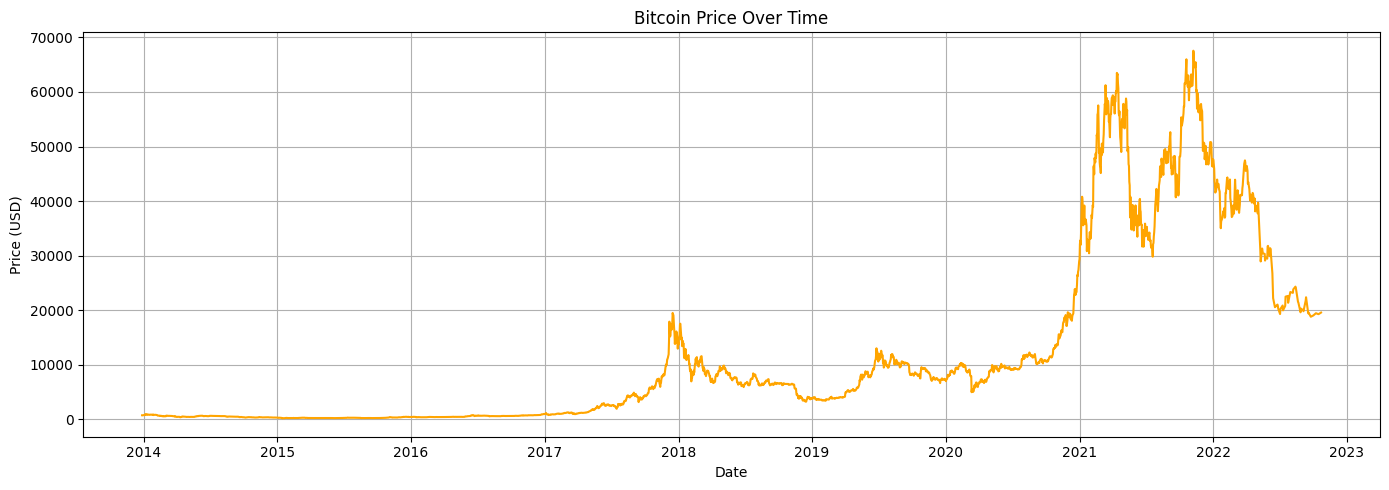

In [3]:
## Bitcoin Price Graph
plt.figure(figsize=(14, 5))
plt.plot(bitcoin.index, bitcoin['close'], color='orange')
plt.title('Bitcoin Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

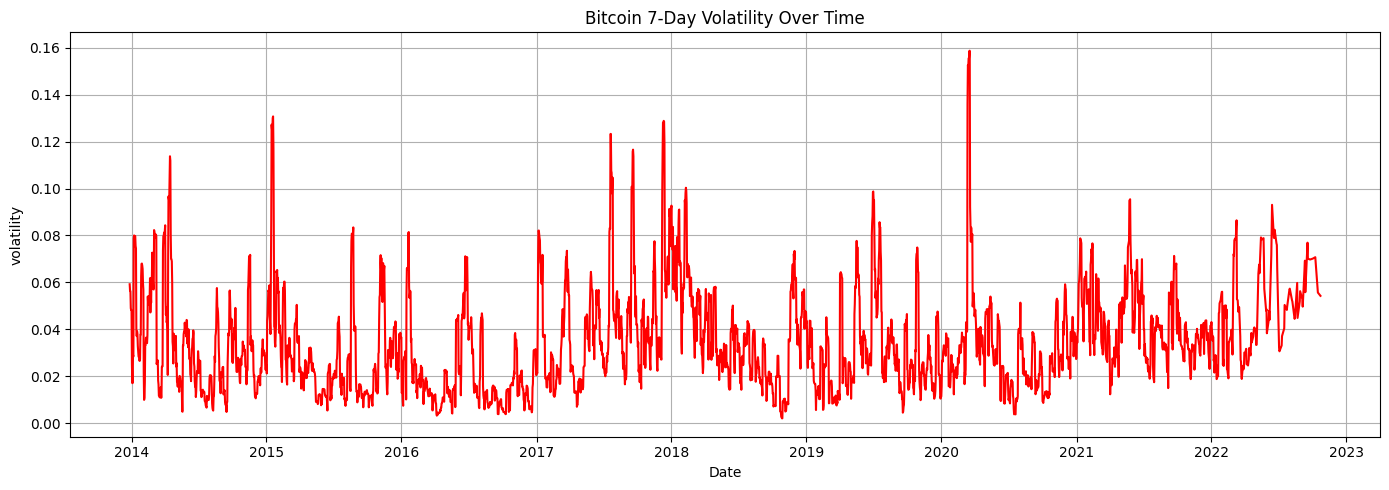

In [4]:
## Volatility Graph
plt.figure(figsize=(14, 5))
plt.plot(bitcoin.index, bitcoin['volatility_7d'], color='red')
plt.title('Bitcoin 7-Day Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('volatility')
plt.grid(True)
plt.tight_layout()
plt.show()

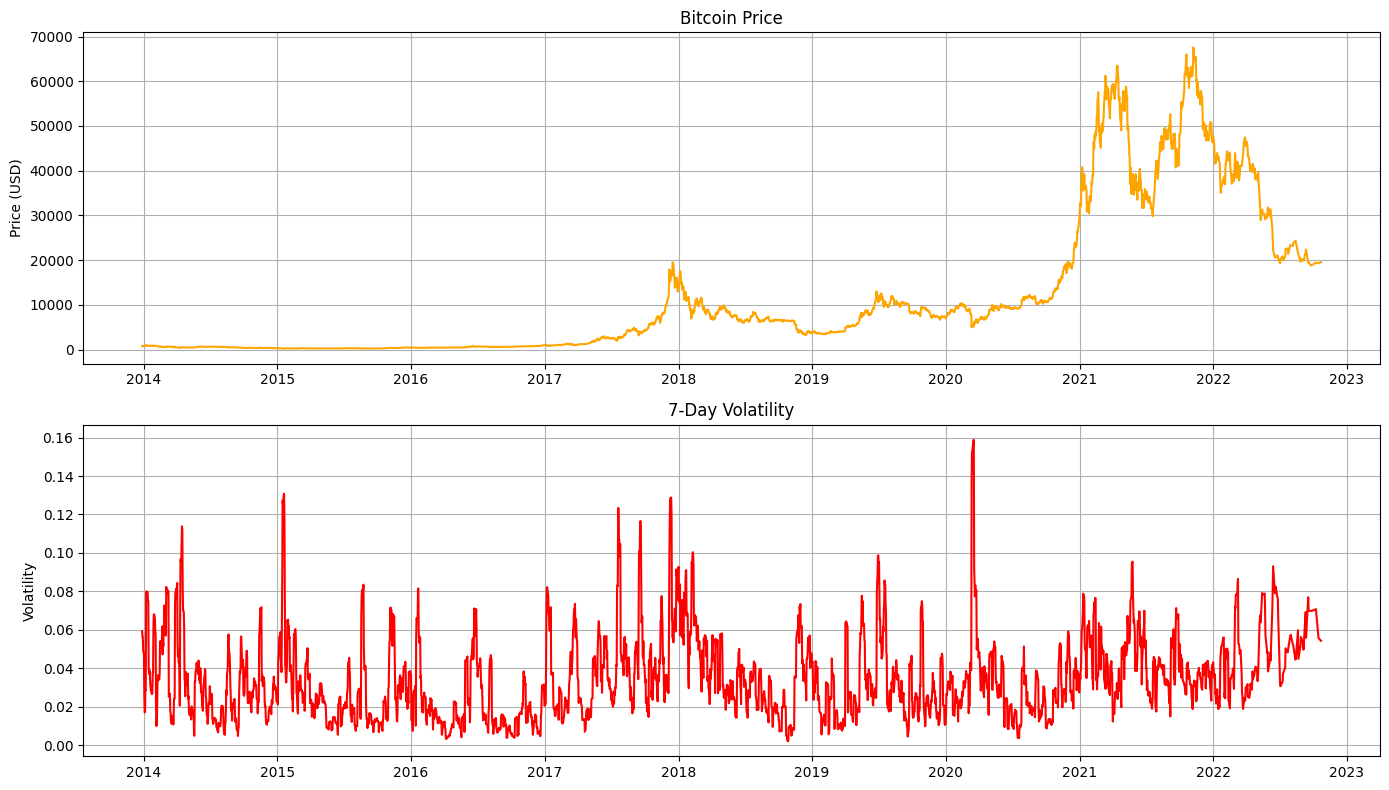

In [5]:
## Combine Price & Volatilityimport pandas as pd
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8))

ax1.plot(bitcoin.index, bitcoin['close'], color='orange')
ax1.set_title('Bitcoin Price')
ax1.set_ylabel('Price (USD)')
ax1.grid(True)

ax2.plot(bitcoin.index, bitcoin['volatility_7d'], color='red')
ax2.set_title('7-Day Volatility')
ax2.set_ylabel('Volatility')
ax2.grid(True)

plt.tight_layout()
plt.show()

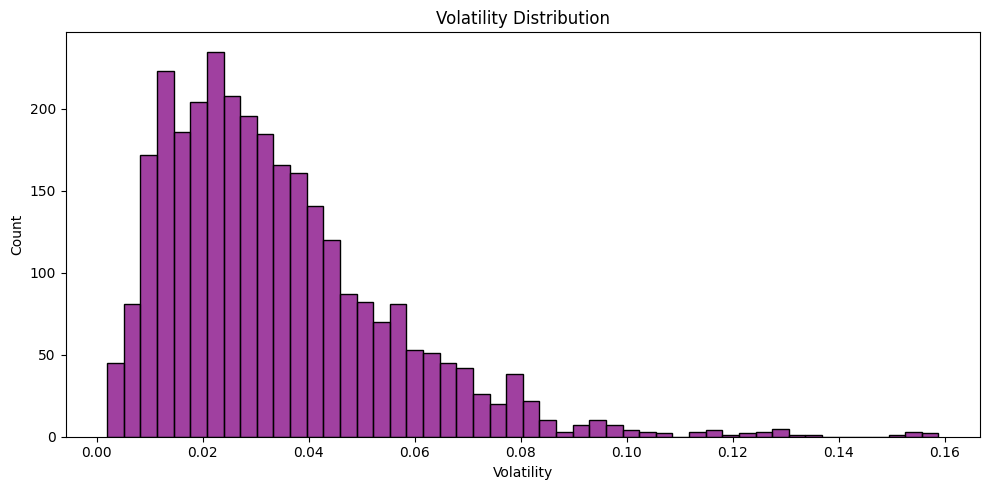

In [6]:
##  Volatility Distribution
plt.figure(figsize=(10,5))
sns.histplot(bitcoin['volatility_7d'], bins=50, color='purple')
plt.title('Volatility Distribution')
plt.xlabel('Volatility')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

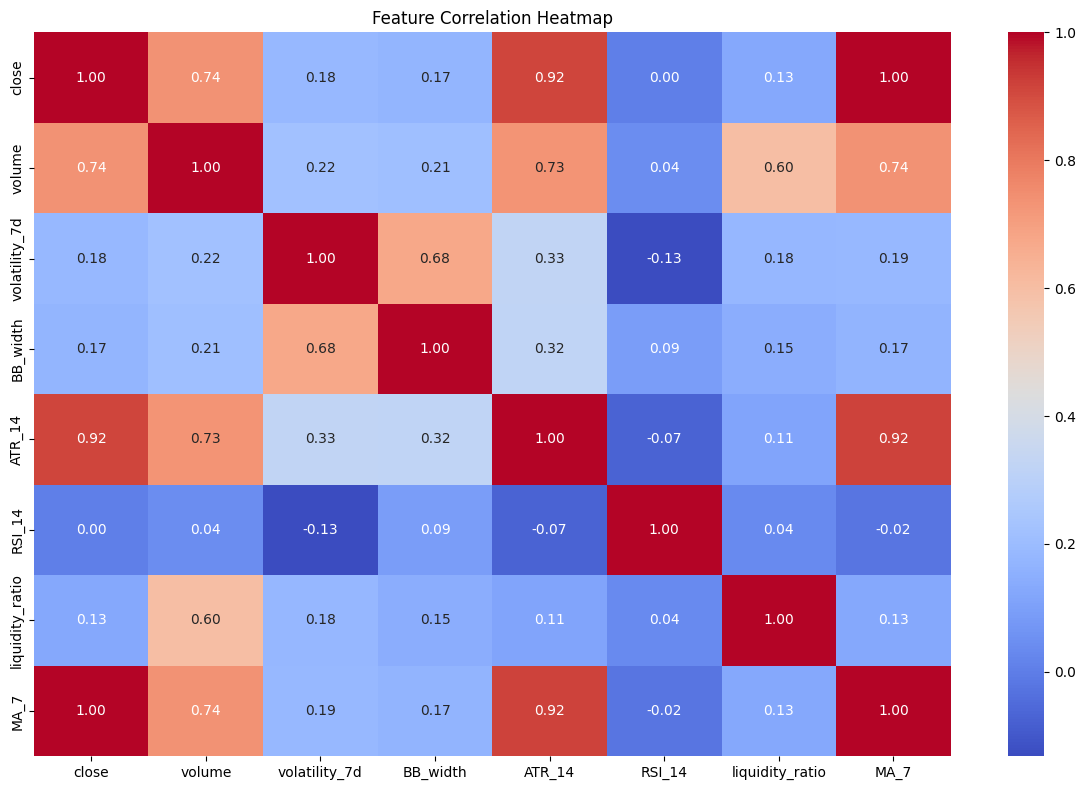

In [7]:
## Correlation heatmap
cols = ['close','volume','volatility_7d','BB_width',
        'ATR_14','RSI_14','liquidity_ratio','MA_7']

plt.figure(figsize=(12,8))
sns.heatmap(bitcoin[cols].corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

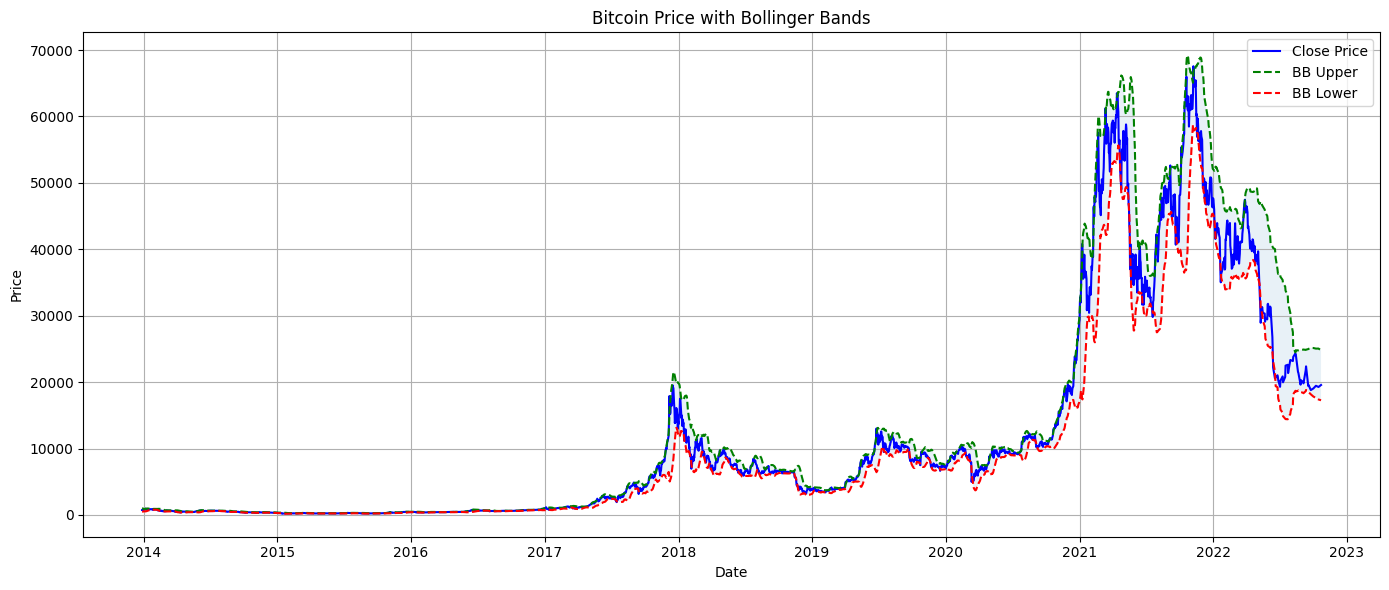

In [8]:
## Bolinger Bands Graph
plt.figure(figsize=(14,6))
plt.plot(bitcoin.index, bitcoin['close'], 
         label='Close Price', color='blue')
plt.plot(bitcoin.index, bitcoin['BB_upper'], 
         label='BB Upper', color='green', linestyle='--')
plt.plot(bitcoin.index, bitcoin['BB_lower'], 
         label='BB Lower', color='red', linestyle='--')
plt.fill_between(bitcoin.index, 
                 bitcoin['BB_upper'], 
                 bitcoin['BB_lower'], alpha=0.1)
plt.title('Bitcoin Price with Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

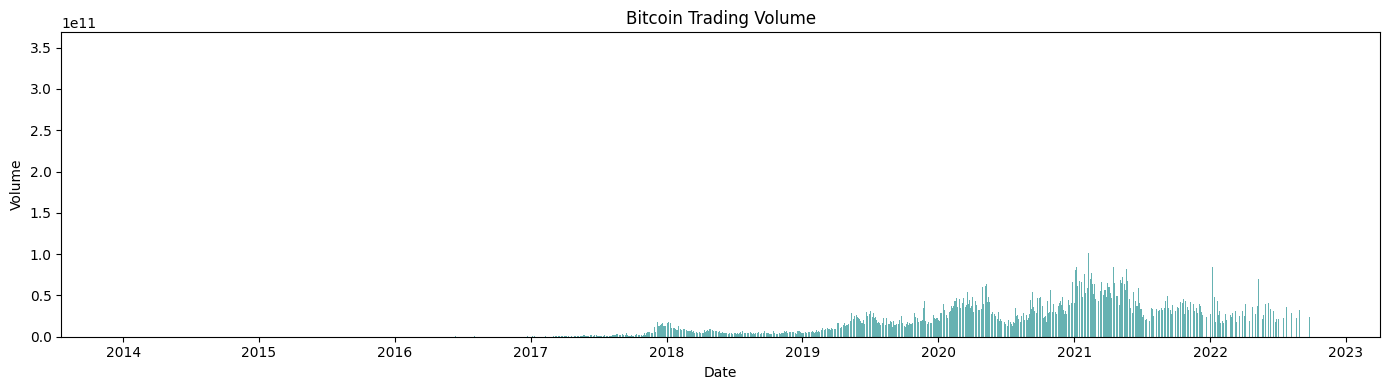

In [9]:
## Volume Graph
plt.figure(figsize=(14,4))
plt.bar(bitcoin.index, bitcoin['volume'], 
        color='teal', alpha=0.6)
plt.title('Bitcoin Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

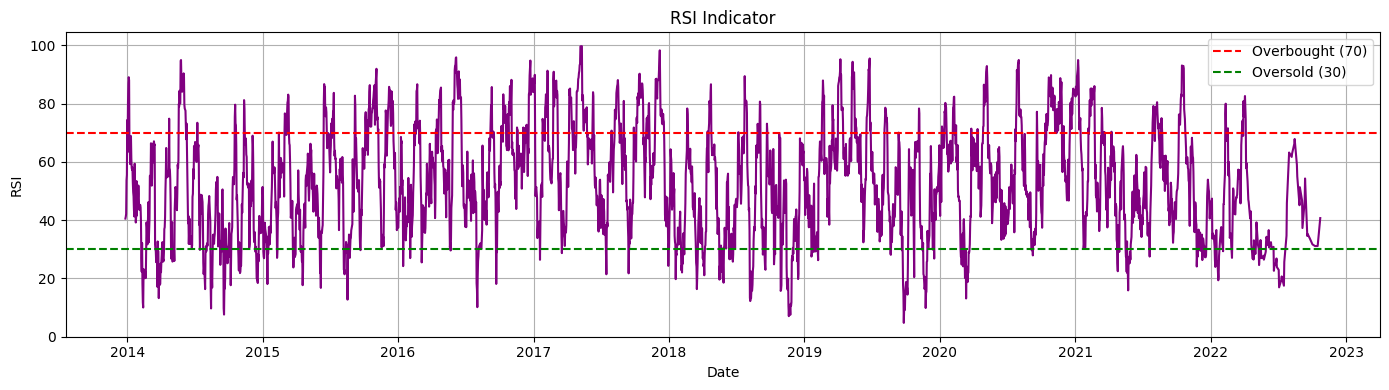

In [10]:
## RSI Graph
plt.figure(figsize=(14,4))
plt.plot(bitcoin.index, bitcoin['RSI_14'], color='purple')
plt.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
plt.title('RSI Indicator')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()